# Part 4: One-Step Generation

In [1]:
from src.model import JiM, JiM_MF
from src.train import train_n_steps, train_n_steps_mf
from src.denoiser import Denoiser, Denoiser_MF
from src.dataloader import get_dataloader

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

## Helpers

In [2]:
device = torch.device("cuda")

In [3]:
def model_tag(dataset, D, pred, loss):
    return f"{dataset}_D{D}_{pred}pred_{loss}loss"


def generate_samples(model, D, pred_type, device, n_gen, steps):
    denoiser = Denoiser(model, steps, D=D)
    return denoiser.generate(n_gen, pred_type, device).cpu().numpy()


def get_ground_truth(dataset, D, n_gen):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n_gen)
    return next(iter(loader))[:n_gen].cpu().numpy()


def project_to_2d(samples, dataset, D):
    if D == 2:
        return samples
    loader = get_dataloader(name=dataset, dim=D, batch_size=1)
    return loader.dataset.to_2d(torch.from_numpy(samples)).numpy()


def density_coverage(gen, real, k=5):
    """Density & Coverage (Naeem et al. 2020) — manifold-aware quality metrics.

    Builds a 'manifold ball' around each real point: radius r_i = distance from
    real_i to its k-th nearest neighbour within the real set (k=5 by default).

    Density = (1 / (k * |gen|)) * sum_{j} sum_{i} 1{ ||gen_j - real_i|| < r_i }
        For every generated point, count how many real-balls contain it; average
        over generated points and divide by k. High Density = generated samples
        land in densely-populated regions of the real manifold (≈ fidelity, the
        'on-manifold' score). Can slightly exceed 1.0 when gen points cluster
        inside heavily-overlapping real-balls.

    Coverage = (1 / |real|) * sum_{i} 1{ min_j ||gen_j - real_i|| < r_i }
        Fraction of real points whose ball contains at least one generated point.
        High Coverage = the real manifold is well covered by generated samples
        (≈ diversity, catches mode collapse). Strictly in [0, 1].

    Both metrics are higher = better, and they're more robust to outliers than
    the older Precision/Recall pair (Kynkäänniemi et al. 2019)."""
    gen, real = np.asarray(gen, dtype=np.float64), np.asarray(real, dtype=np.float64)

    # Pairwise distances (real-real and gen-real). N is small (2k×2k ⇒ ~33 MB), fine.
    dr  = np.sqrt(((real[:, None, :] - real[None, :, :]) ** 2).sum(-1))
    dgr = np.sqrt(((gen[:,  None, :] - real[None, :, :]) ** 2).sum(-1))

    # Radius to k-th nearest *other* real point. Self-distance is 0 (column 0
    # after sorting), so column k gives the k-th NN.
    radii = np.sort(dr, axis=1)[:, k]                       # (N,)

    # Density: gen × real boolean of "is gen_j inside real_i's ball?"
    inside  = dgr < radii[None, :]                          # (M, N)
    density = float(inside.sum(axis=1).mean() / k)

    # Coverage: a real point is "covered" iff its nearest gen point is inside
    # its own ball. Equivalent to "at least one gen point in the ball".
    nearest_gen = dgr.min(axis=0)                           # (N,)
    coverage = float((nearest_gen < radii).mean())

    return density, coverage

def plot_grid(steps, D, pred, loss, h, n_gen, device, MODEL_DIR, FIG_DIR):
    """One figure per dataset: rows = D in {2, 8, 32}, cols = [GT, 4 pred/loss combos].
    GT cell shows ground truth in orange; remaining cells overlay generated (blue) on GT (gray).
    Per-row axis limits are fixed from the ground-truth extent so every subplot has identical
    dimensions; far-out generated points are clipped rather than rescaling the view."""
    n_rows = 3
    n_cols = len(steps) + 1

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        squeeze=False,
    )

    for row, dataset in enumerate(("swiss_roll", "gaussians", "circles")):
        gt = get_ground_truth(dataset, D, n_gen)
        gt2d = project_to_2d(gt, dataset, D)

        # Square, padded limits derived from GT only — shared across the row.
        x_min, x_max = gt2d[:, 0].min(), gt2d[:, 0].max()
        y_min, y_max = gt2d[:, 1].min(), gt2d[:, 1].max()
        cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
        half = 0.6 * max(x_max - x_min, y_max - y_min)
        xlim = (cx - half, cx + half)
        ylim = (cy - half, cy + half)

        ax_gt = axes[row, 0]
        ax_gt.scatter(gt2d[:, 0], gt2d[:, 1], s=3, alpha=0.6, c="orange")
        ax_gt.set_title(f"Ground Truth: {dataset}", fontsize=11)
        ax_gt.set_aspect("equal")
        ax_gt.set_xlim(xlim); ax_gt.set_ylim(ylim)
        ax_gt.set_xticks([]); ax_gt.set_yticks([])

        for offset, step in enumerate(steps):
            col = offset + 1
            ax = axes[row, col]
            tag = model_tag(dataset, D, pred, loss)

            model = JiM(hidden_dim=h, D=D).to(device)
            model.load_state_dict(torch.load(MODEL_DIR / f"{tag}.pt", map_location=device))
            model.eval()

            gen = generate_samples(model, D, pred, device, n_gen, step)
            gen2d = project_to_2d(gen, dataset, D)

            dens, cov = density_coverage(gen2d, gt2d)
            ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray", label="ground truth")
            ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0",   label="generated")
            ax.set_title(f"STEPS: {step}", fontsize=11)
            ax.set_aspect("equal")
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_xticks([]); ax.set_yticks([])

            ax.text(0.02, 0.98, f"Dens {dens:.2f}\nCov  {cov:.2f}",
                    transform=ax.transAxes, ha="left", va="top", fontsize=9,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                            edgecolor="none", alpha=0.85))

    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.suptitle(f"Sampling Efficiency", fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sampling_efficiency.png", dpi=150, bbox_inches="tight")
    plt.show()

## Q1) Sampling Efficiency

In [4]:
MODEL_DIR = Path("models/part2")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("res/part4")
FIG_DIR.mkdir(parents=True, exist_ok=True)

STEPS = (1, 2, 5, 10, 20, 50, 100, 200)

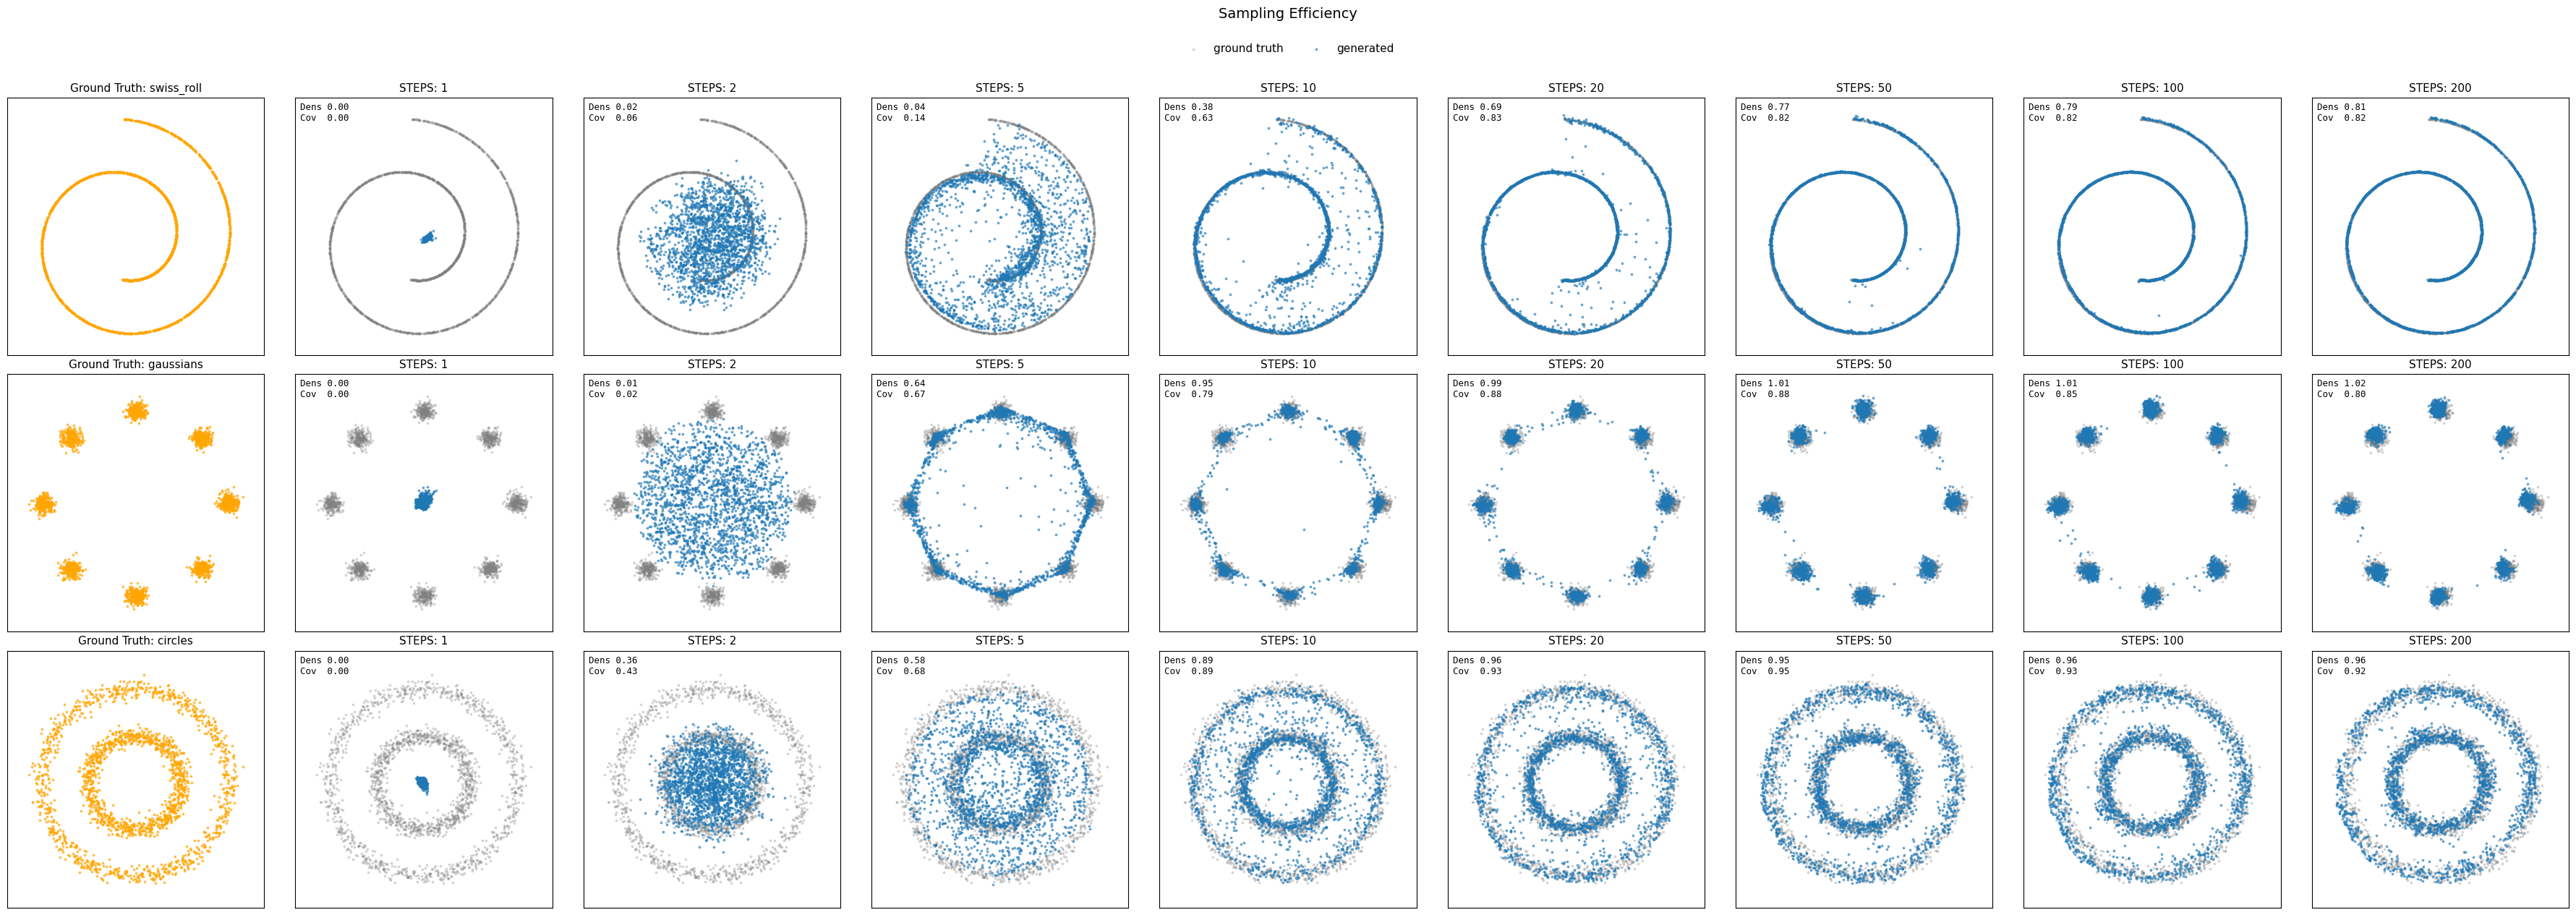

In [5]:
plot_grid(
    steps=STEPS, 
    D=2,
    pred='x', 
    loss='v', 
    h=256, 
    n_gen=2048, 
    device=device,
    MODEL_DIR=MODEL_DIR,
    FIG_DIR=FIG_DIR
)

## Q2.

In [5]:
D = 32
dataset = "gaussians"
MODEL_DIR = Path("models/part4")
MODEL2_DIR = Path("models/part2")
pred = 'x'
loss = 'v'
TRAIN_STEPS = 25000

In [6]:
def generate_samples(model, D, device, n_gen, steps):
    denoiser = Denoiser_MF(model, steps, D=D)
    return denoiser.generate(n_gen, device).cpu().numpy()

def get_ground_truth(dataset, D, n_gen):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n_gen)
    return next(iter(loader))[:n_gen].cpu().numpy()

import time, json

def train_one_config(dataset, D, h, device, n_steps=25_000):
    dataloader = get_dataloader(name=dataset, dim=D, batch_size=1024)
    model = JiM_MF(hidden_dim=h, D=D).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)

    t0 = time.time()
    losses = train_n_steps_mf(model, dataloader, opt, device, n_steps)
    train_time_s = time.time() - t0

    tag = f"{dataset}_D{D}_h{h}_MF"
    torch.save(model.state_dict(), MODEL_DIR / f"{tag}.pt")
    np.save(MODEL_DIR / f"{tag}_losses.npy", np.asarray(losses, dtype=np.float32))

    meta = {
        "tag": tag, "dataset": dataset, "D": D, "h": h,
        "n_steps": n_steps,
        "train_time_s": train_time_s,
        "n_params": sum(p.numel() for p in model.parameters()),
        "method": "MF",
    }
    (MODEL_DIR / f"{tag}_meta.json").write_text(json.dumps(meta, indent=2))
    return model

In [7]:
def plot_mf_vs_fm_grid(dataset, D, h, pred, loss, n_gen, device, MODEL_DIR, MODEL2_DIR, FIG_DIR):
    """One figure per dataset at fixed D.
    Row 0 (FM): [GT, FM 1, FM 20, FM 50]
    Row 1 (MF): [GT, MF 1, MF 2,  MF 5]
    Generated samples (blue) overlaid on GT (gray), with density/coverage annotated."""
    records = []
    
    fm_steps = [1, 10, 50]
    mf_steps = [1, 2, 5]
    n_rows, n_cols = 2, 4

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        squeeze=False,
    )

    gt = get_ground_truth(dataset, D, n_gen)
    gt2d = project_to_2d(gt, dataset, D)

    x_min, x_max = gt2d[:, 0].min(), gt2d[:, 0].max()
    y_min, y_max = gt2d[:, 1].min(), gt2d[:, 1].max()
    cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
    half = 0.6 * max(x_max - x_min, y_max - y_min)
    xlim, ylim = (cx - half, cx + half), (cy - half, cy + half)

    def style(ax, title):
        ax.set_title(title, fontsize=11)
        ax.set_aspect("equal")
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_xticks([]); ax.set_yticks([])

    def annotate(ax, dens, cov):
        ax.text(0.02, 0.98, f"Dens {dens:.2f}\nCov  {cov:.2f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=9, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="none", alpha=0.85))

    # Column 0: GT in both rows
    for row, label in enumerate(("Flow Matching", "MeanFlow")):
        ax = axes[row, 0]
        ax.scatter(gt2d[:, 0], gt2d[:, 1], s=3, alpha=0.6, c="orange")
        style(ax, f"GT — {label}")

    # Row 0: Flow Matching
    fm_tag = model_tag(dataset, D, pred, loss)
    fm_model = JiM(hidden_dim=h, D=D).to(device)
    fm_model.load_state_dict(torch.load(MODEL2_DIR / f"{fm_tag}.pt", map_location=device))
    fm_model.eval()


    for offset, step in enumerate(fm_steps):
        ax = axes[0, offset + 1]
        denoiser = Denoiser(fm_model, step, D=D)
        gen = denoiser.generate(n_gen, pred, device).cpu().numpy()
        gen2d = project_to_2d(gen, dataset, D)
        dens, cov = density_coverage(gen2d, gt2d)

        records.append({
            "dataset": dataset, "D": D, "method": "FM", "steps": step,
            "density": dens, "coverage": cov, "model_tag": fm_tag,
        })

        ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray")
        ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0")
        style(ax, f"FM, STEPS: {step}")
        annotate(ax, dens, cov)

        # Row 1: MeanFlow (load or train if missing)
        mf_tag = f"{dataset}_D{D}_h{h}_MF"
        mf_path = MODEL_DIR / f"{mf_tag}.pt"
        if mf_path.exists():
            mf_model = JiM_MF(hidden_dim=h, D=D).to(device)
            mf_model.load_state_dict(torch.load(mf_path, map_location=device))
        else:
            print(f"  [{mf_tag}] not found — training now")
            mf_model = train_one_config(dataset, D, h, device, n_steps=25000)   # saves to MODEL_DIR via the global
        mf_model.eval()

    for offset, step in enumerate(mf_steps):
        ax = axes[1, offset + 1]
        denoiser = Denoiser_MF(mf_model, step, D=D)
        gen = denoiser.generate(n_gen, device).cpu().numpy()
        gen2d = project_to_2d(gen, dataset, D)
        dens, cov = density_coverage(gen2d, gt2d)

        records.append({
            "dataset": dataset, "D": D, "method": "MF", "steps": step,
            "density": dens, "coverage": cov, "model_tag": mf_tag,
        })

        ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray")
        ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0")
        style(ax, f"MF, STEPS: {step}")
        annotate(ax, dens, cov)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=6, label='ground truth'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='C0',   markersize=6, label='generated'),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.suptitle(f"MeanFlow vs. Flow Matching — {dataset} (D={D})", fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"mf_vs_fm_{dataset}_D{D}.png", dpi=150, bbox_inches="tight")

    (FIG_DIR / f"results_{dataset}_D{D}.json").write_text(json.dumps(records, indent=2))

    plt.show()

In [8]:
def collect_part4(datasets, D, FIG_DIR, MODEL_DIR, MODEL2_DIR):
    """Pull density/coverage from results.json + train time from each model's meta.json."""
    all_rows = []
    for dataset in datasets:
        rp = FIG_DIR / f"results_{dataset}_D{D}.json"
        if not rp.exists():
            continue
        for r in json.loads(rp.read_text()):
            method_dir = MODEL_DIR if r["method"] == "MF" else MODEL2_DIR
            meta_path = method_dir / f"{r['model_tag']}_meta.json"
            r["train_time_s"] = None
            if meta_path.exists():
                r["train_time_s"] = json.loads(meta_path.read_text()).get("train_time_s")
            all_rows.append(r)
    return all_rows


def print_part4_table(rows):
    header = (f"{'dataset':<14}{'method':>7}{'steps':>7}  "
              f"{'Density':>9}{'Coverage':>10}  {'train':>10}")
    print(header)
    print("-" * len(header))
    for r in rows:
        t = fmt_time(r.get("train_time_s"))
        print(f"{r['dataset']:<14}{r['method']:>7}{r['steps']:>7}  "
              f"{r['density']:>9.3f}{r['coverage']:>10.3f}  {t:>10}")

  [swiss_roll_D32_h256_MF] not found — training now
step    500/25000  loss 0.326745
step   1000/25000  loss 0.080538
step   1500/25000  loss 0.072190
step   2000/25000  loss 0.069079
step   2500/25000  loss 0.076818
step   3000/25000  loss 0.067324
step   3500/25000  loss 0.073363
step   4000/25000  loss 0.069719
step   4500/25000  loss 0.070773
step   5000/25000  loss 0.071323
step   5500/25000  loss 0.071501
step   6000/25000  loss 0.074349
step   6500/25000  loss 0.071712
step   7000/25000  loss 0.069553
step   7500/25000  loss 0.074697
step   8000/25000  loss 0.072355
step   8500/25000  loss 0.071381
step   9000/25000  loss 0.072128
step   9500/25000  loss 0.072087
step  10000/25000  loss 0.074217
step  10500/25000  loss 0.074816
step  11000/25000  loss 0.072646
step  11500/25000  loss 0.073501
step  12000/25000  loss 0.074979
step  12500/25000  loss 0.075637
step  13000/25000  loss 0.073471
step  13500/25000  loss 0.075428
step  14000/25000  loss 0.077234
step  14500/25000  loss 

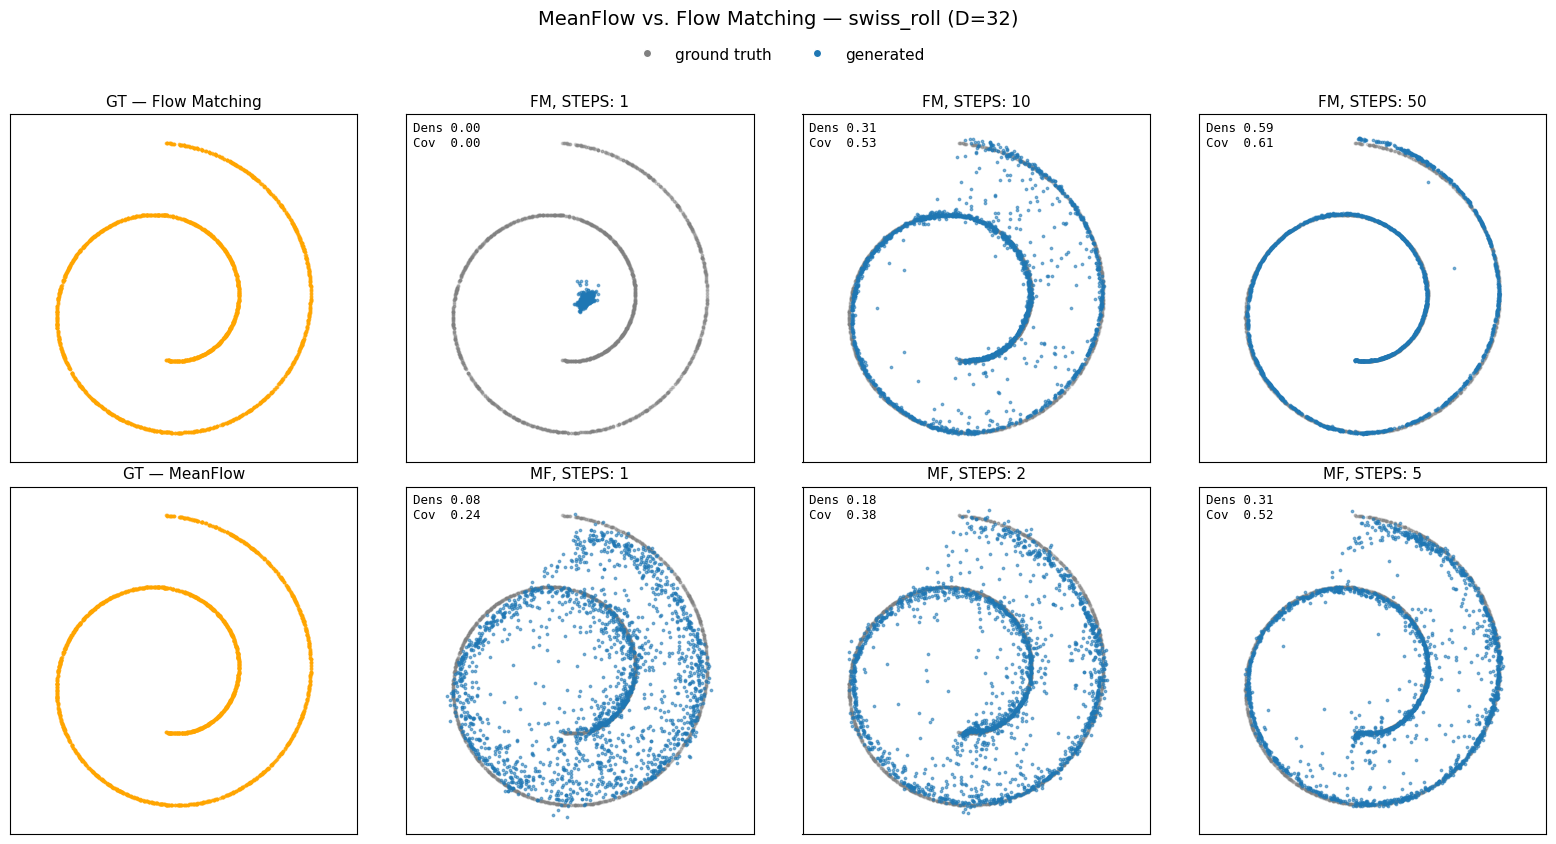

  [gaussians_D32_h256_MF] not found — training now
step    500/25000  loss 0.321841
step   1000/25000  loss 0.071529
step   1500/25000  loss 0.075822
step   2000/25000  loss 0.077580
step   2500/25000  loss 0.077102
step   3000/25000  loss 0.077525
step   3500/25000  loss 0.080698
step   4000/25000  loss 0.080073
step   4500/25000  loss 0.082089
step   5000/25000  loss 0.081596
step   5500/25000  loss 0.083539
step   6000/25000  loss 0.083666
step   6500/25000  loss 0.084034
step   7000/25000  loss 0.086010
step   7500/25000  loss 0.086567
step   8000/25000  loss 0.086580
step   8500/25000  loss 0.088327
step   9000/25000  loss 0.087131
step   9500/25000  loss 0.090051
step  10000/25000  loss 0.091243
step  10500/25000  loss 0.091459
step  11000/25000  loss 0.090965
step  11500/25000  loss 0.087519
step  12000/25000  loss 0.090188
step  12500/25000  loss 0.091655
step  13000/25000  loss 0.093765
step  13500/25000  loss 0.091687
step  14000/25000  loss 0.093971
step  14500/25000  loss 0

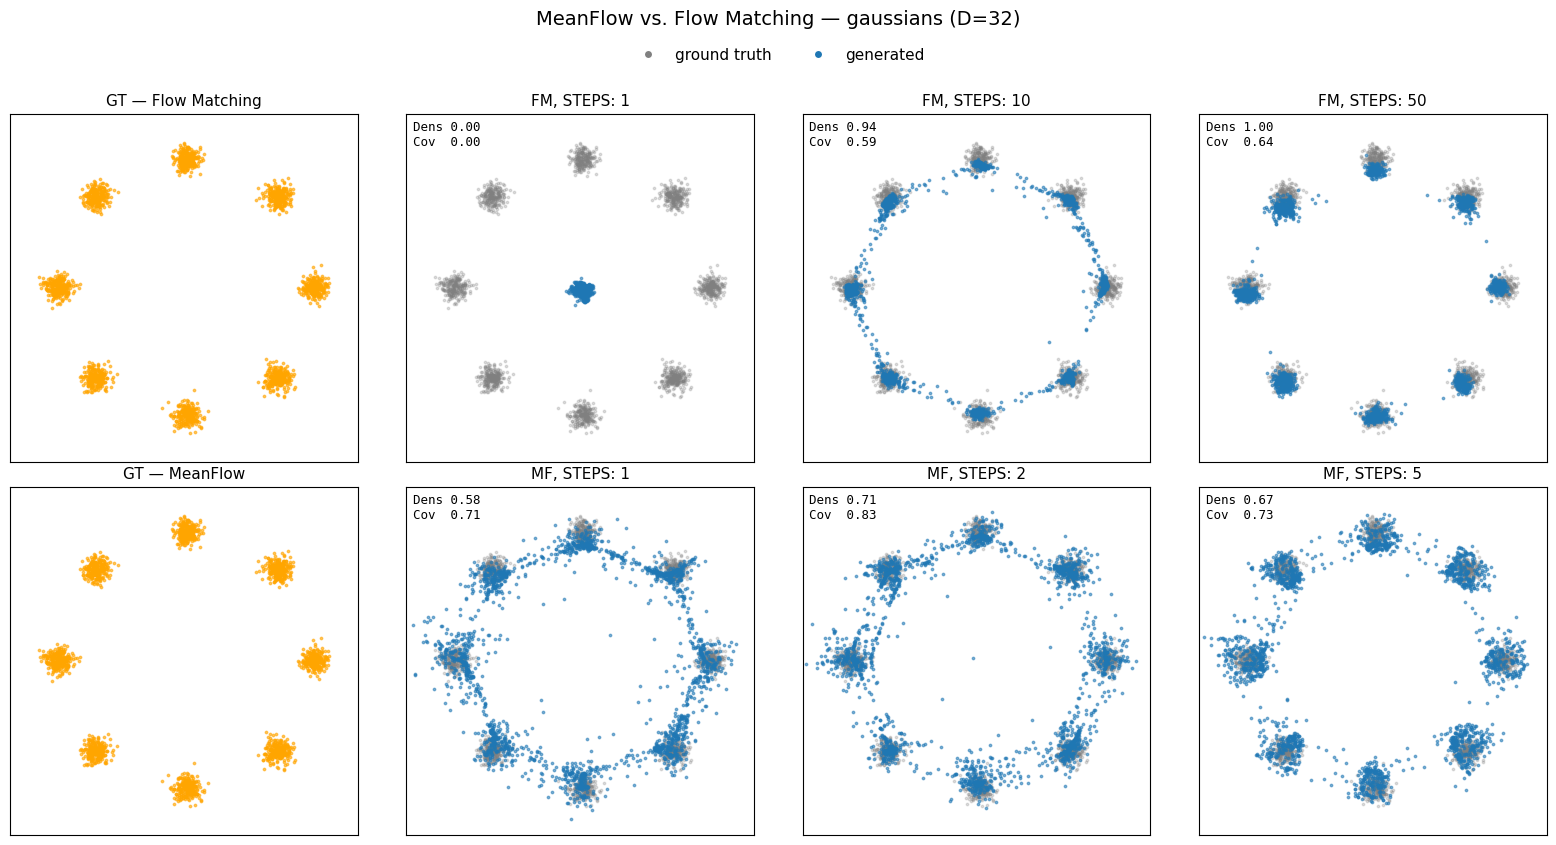

  [circles_D32_h256_MF] not found — training now
step    500/25000  loss 0.237553
step   1000/25000  loss 0.058791
step   1500/25000  loss 0.061143
step   2000/25000  loss 0.059108
step   2500/25000  loss 0.057481
step   3000/25000  loss 0.060734
step   3500/25000  loss 0.058725
step   4000/25000  loss 0.060984
step   4500/25000  loss 0.058310
step   5000/25000  loss 0.056139
step   5500/25000  loss 0.057546
step   6000/25000  loss 0.059549
step   6500/25000  loss 0.057228
step   7000/25000  loss 0.056502
step   7500/25000  loss 0.057986
step   8000/25000  loss 0.058948
step   8500/25000  loss 0.055679
step   9000/25000  loss 0.058956
step   9500/25000  loss 0.055231
step  10000/25000  loss 0.056450
step  10500/25000  loss 0.057637
step  11000/25000  loss 0.057256
step  11500/25000  loss 0.055508
step  12000/25000  loss 0.055860
step  12500/25000  loss 0.057137
step  13000/25000  loss 0.055523
step  13500/25000  loss 0.056232
step  14000/25000  loss 0.055626
step  14500/25000  loss 0.0

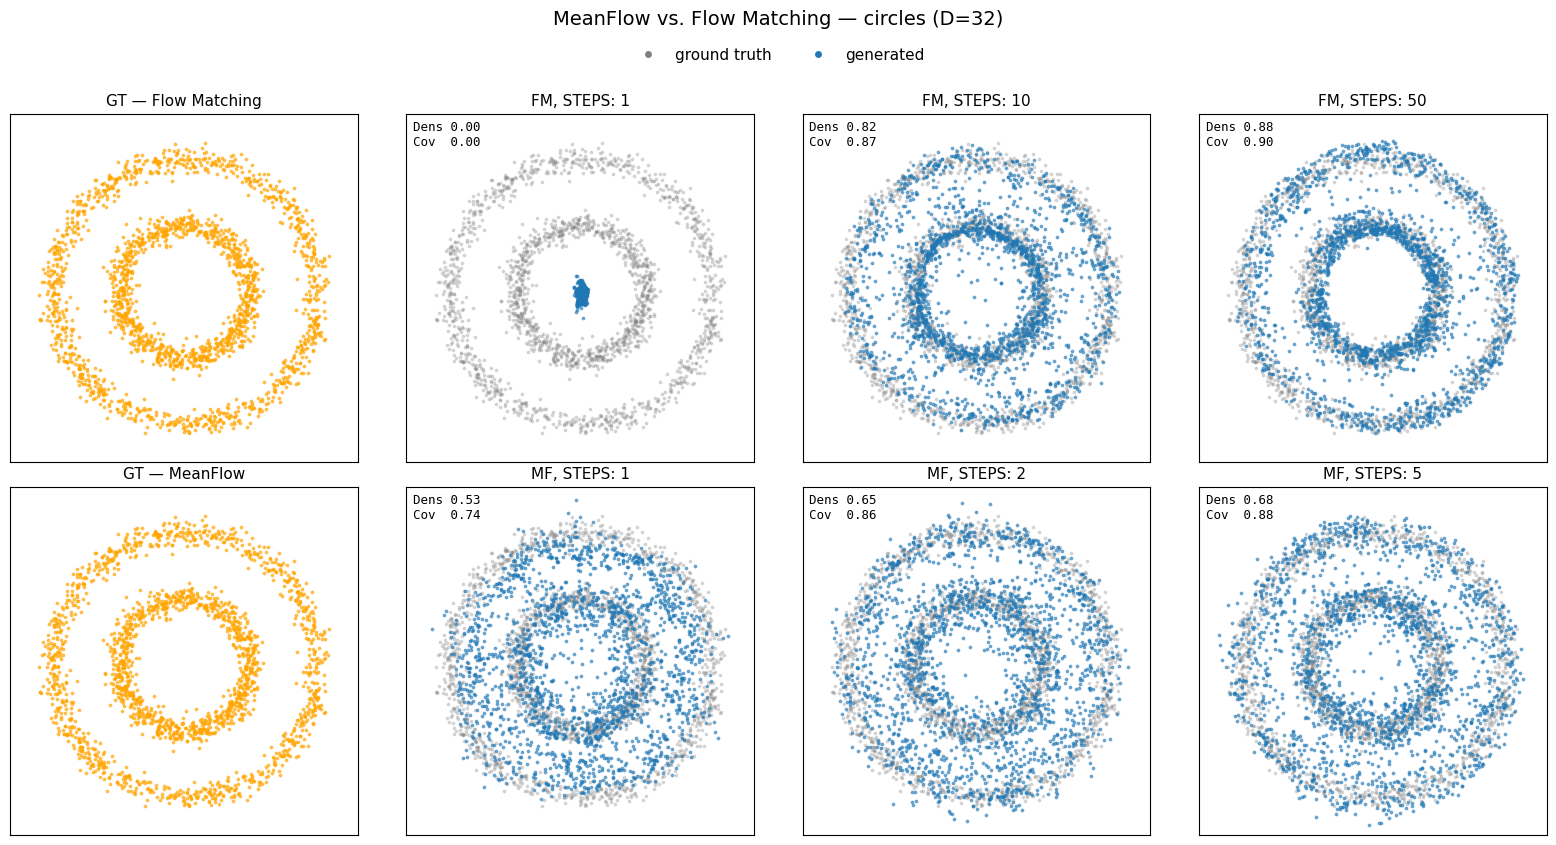

In [9]:
for dataset in ("swiss_roll", "gaussians", "circles"):
    plot_mf_vs_fm_grid(
        dataset=dataset, D=32, h=256,
        pred='x', loss='v',          # best model xpred with vloss
        n_gen=2048, device=device,
        MODEL_DIR=MODEL_DIR, MODEL2_DIR=MODEL2_DIR, 
        FIG_DIR=FIG_DIR,
    )

In [11]:
def fmt_time(s):
    if s is None:
        return "—"
    m, s = divmod(int(s), 60)
    return f"{m}m {s:>2}s"

In [12]:
AVAILABLE_DATASETS = ("swiss_roll", "gaussians", "circles")
rows = collect_part4(AVAILABLE_DATASETS, D=32, FIG_DIR=FIG_DIR, MODEL_DIR=MODEL_DIR, MODEL2_DIR=MODEL2_DIR)
print_part4_table(rows)

dataset        method  steps    Density  Coverage       train
-------------------------------------------------------------
swiss_roll         FM      1      0.000     0.000           —
swiss_roll         FM     10      0.308     0.530           —
swiss_roll         FM     50      0.589     0.606           —
swiss_roll         MF      1      0.081     0.236      1m 35s
swiss_roll         MF      2      0.180     0.384      1m 35s
swiss_roll         MF      5      0.313     0.523      1m 35s
gaussians          FM      1      0.000     0.000           —
gaussians          FM     10      0.943     0.589           —
gaussians          FM     50      0.998     0.638           —
gaussians          MF      1      0.583     0.707      1m 35s
gaussians          MF      2      0.712     0.832      1m 35s
gaussians          MF      5      0.670     0.727      1m 35s
circles            FM      1      0.000     0.000           —
circles            FM     10      0.816     0.873           —
circles 